In [1]:
import torch
import neml2
from pyzag import nonlinear, reparametrization, chunktime
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import os
import re
import tqdm
import pandas as pd
from scipy.optimize import brentq
from neml2.cli.inspect import main as inspect_main
import math

In [2]:
torch.manual_seed(0)

torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
device = torch.device(dev)

CUDA is available
CUDA version: 13.0


In [3]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
    """

    def __init__(
        self,
        discrete_equations,
        nchunk=1,
        rtol=1.0e-6,
        atol=1.0e-4,
        initial_rho_m=90.0,
        initial_tau_ss=100.0,
    ):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.cached_solution = None
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m
        self.initial_tau_ss = initial_tau_ss

    def forward(self, time, temperature, loading, cache=False):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder

        Keyword Args:
            cache (bool): if true, cache the solution and use it as a predictor for the next call.
                This heuristic can speed things up during inference where the model is called repeatedly with similar parameter values.
        """
        if cache and self.cached_solution is not None:
            solver = nonlinear.RecursiveNonlinearEquationSolver(
                self.discrete_equations,
                step_generator=nonlinear.StepGenerator(self.nchunk),
                predictor=nonlinear.FullTrajectoryPredictor(self.cached_solution),  # type: ignore
                nonlinear_solver=chunktime.ChunkNewtonRaphson(
                    rtol=self.rtol, atol=self.atol, throw_on_fail=False
                ),
            )
        else:
            solver = nonlinear.RecursiveNonlinearEquationSolver(
                self.discrete_equations,
                step_generator=nonlinear.StepGenerator(self.nchunk),
                predictor=nonlinear.PreviousStepsPredictor(),  # type: ignore
                nonlinear_solver=chunktime.ChunkNewtonRaphson(
                    rtol=self.rtol, atol=self.atol, throw_on_fail=False
                ),
            )

        control = torch.zeros_like(loading)
        control[..., 1:] = 1.0

        # Pack the per-force raw tensors into the single flat forces tensor
        # pyzag consumes. ``assemble_forces`` uses the adapter's own force
        # layout, so the packing is guaranteed to match how the factory later
        # splits the tensor back apart (``_split_by_layout``); base sizes come
        # from the layout, so scalars need no trailing-1 unsqueeze here.
        forces = self.discrete_equations.assemble_forces(
            {
                "t": time,
                "temperature": temperature,
                "fixed_values": loading,
                "control": control,
            }
        )
        state0 = self.discrete_equations.assemble_state(
            {
                "mixed_state": torch.zeros(forces.shape[1:-1] + (6,), device=forces.device),
                "log_rho_m": torch.full(
                    forces.shape[1:-1], math.log(self.initial_rho_m), device=forces.device
                ),
                "back_stress": torch.zeros(forces.shape[1:-1] + (6,), device=forces.device),
                "tau_ss": torch.full(forces.shape[1:-1], self.initial_tau_ss, device=forces.device),
            }
        )

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)

        if cache:
            self.cached_solution = result.detach().clone()

        if not torch.isfinite(result).all():
            raise RuntimeError(
                "Non-finite state in the integrated solution: the solve produced NaN/Inf "
                "that pyzag's convergence test did not catch. Reduce nchunk or the step size."
            )

        return result[..., 0:1]

    def density(self, result):
        """Physical mobile dislocation density (um^{-2}) from a solved trajectory."""
        return torch.exp(result[..., 6:7])

In [4]:
nmodel = neml2.load_nonlinear_system("eurofer97.i", "eq_sys")
nmodel.to(device=device)
pmodel = neml2.pyzag.NEML2PyzagModel(
    nmodel,
    include_parameters=[
        "rho_m_rate_k1",
        "rho_m_rate_k2_0",
        "rho_m_rate_Q_d",
        "v_disl_B_k",
        "v_disl_T_0",
        "v_disl_p",
        "v_disl_q",
        "v_disl_H_0",
        "kinharden_C",
        "kinharden_g",
    ],
)
neml2.compile(pmodel)

model = SolveStrain(pmodel)
_ = inspect_main(["eurofer97.i", "implicit_rate"])

Model: ComposedModel

Inputs (15):
  log_rho_m: type=Scalar
  control: type=SR2
  fixed_values: type=SR2
  mixed_state: type=SR2
  control~1: type=SR2
  fixed_values~1: type=SR2
  mixed_state~1: type=SR2
  temperature: type=Scalar
  t: type=Scalar
  t~1: type=Scalar
  back_stress: type=SR2
  tau_ss: type=Scalar
  back_stress~1: type=SR2
  tau_ss~1: type=Scalar
  log_rho_m~1: type=Scalar

Outputs (4):
  back_stress_residual: type=SR2
  tau_ss_residual: type=Scalar
  log_rho_m_residual: type=Scalar
  stress_residual: type=SR2

Parameters (57):
  rho_m_from_log.scaling: dtype=torch.float64, device=cpu, shape=[]
  rho_m_from_log.rate: dtype=torch.float64, device=cpu, shape=[]
  E.a: dtype=torch.float64, device=cpu, shape=[]
  E.b: dtype=torch.float64, device=cpu, shape=[]
  E.c: dtype=torch.float64, device=cpu, shape=[]
  nu.a: dtype=torch.float64, device=cpu, shape=[]
  nu.b: dtype=torch.float64, device=cpu, shape=[]
  nu.c: dtype=torch.float64, device=cpu, shape=[]
  L.c_lath: dtype=torc

0.3%: 252 points, loop uses 88 (strain -0.296% to 0.307%)
0.7%: 274 points, loop uses 116 (strain -0.699% to 0.701%)


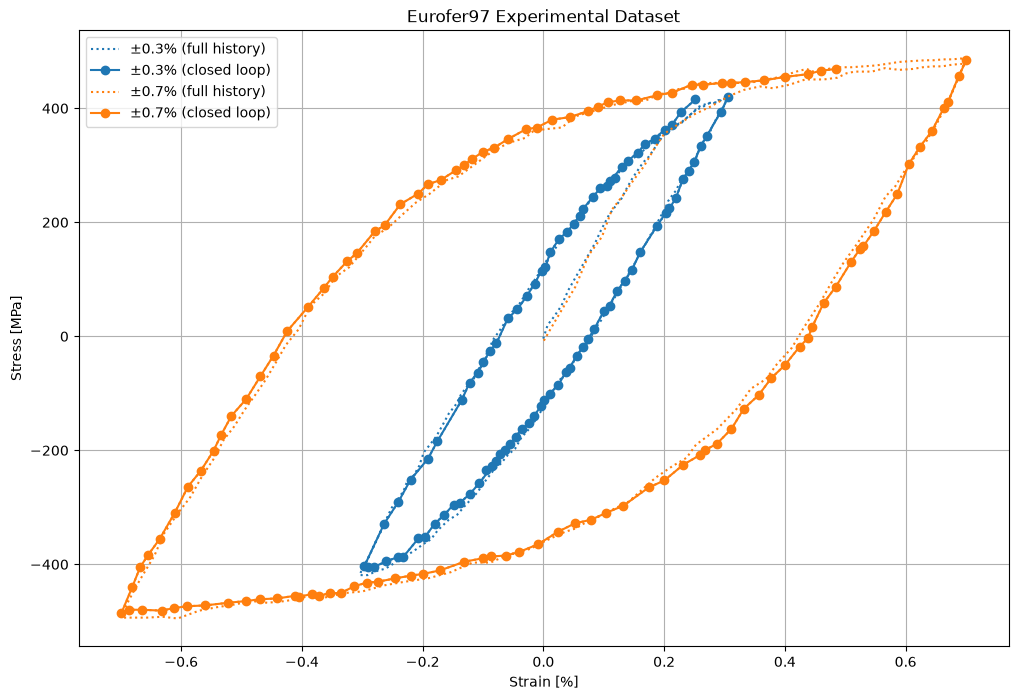

In [5]:
path = "cyclic_data"
amp_labels = ["0.3", "0.7"]

raw_strain = {}
raw_stress = {}
loop_strain = {}
loop_stress = {}

for amp in amp_labels:
    (filenames,) = [
        f for f in os.listdir(path) if f.startswith("Eurofer97") and amp in f and f.endswith(".csv")
    ]
    df = pd.read_csv(os.path.join(path, filenames))

    strain = (
        torch.tensor(df["x"].values, device=device) * 1.0e-2
    )  # convert from percent to real strain
    stress = torch.tensor(df["y"].values, device=device)
    raw_strain[amp] = strain
    raw_stress[amp] = stress

    i_peak = int(torch.argmax(strain))
    loop_strain[amp] = strain[i_peak:]
    loop_stress[amp] = stress[i_peak:]
    print(
        f"{amp}%: {len(raw_strain[amp])} points, loop uses {len(loop_strain[amp])} "
        f"(strain {loop_strain[amp].min() * 100:.3f}% to {loop_strain[amp].max() * 100:.3f}%)"
    )
plt.figure(figsize=(12, 8))
for i, amp in enumerate(amp_labels):
    plt.plot(
        raw_strain[amp].cpu().numpy() * 100,
        raw_stress[amp].cpu().numpy(),
        ":",
        color=f"C{i}",
        label=rf"$\pm${amp}% (full history)",
    )
    plt.plot(
        loop_strain[amp].cpu().numpy() * 100,
        loop_stress[amp].cpu().numpy(),
        "-o",
        color=f"C{i}",
        label=rf"$\pm${amp}% (closed loop)",
    )
plt.xlabel("Strain [%]")
plt.ylabel("Stress [MPa]")
plt.title("Eurofer97 Experimental Dataset")
plt.legend()
plt.grid()

In [ ]:
disp_rate = 0.014
gauge_length = 2
strain_rate = disp_rate / gauge_length

ranges = torch.tensor([0.003, 0.007], device=device)
temperatures = torch.tensor([300.0], device=device)
n_cycles = 3
points_per_cycle = 80
ntime = n_cycles * points_per_cycle
nbatch = 2

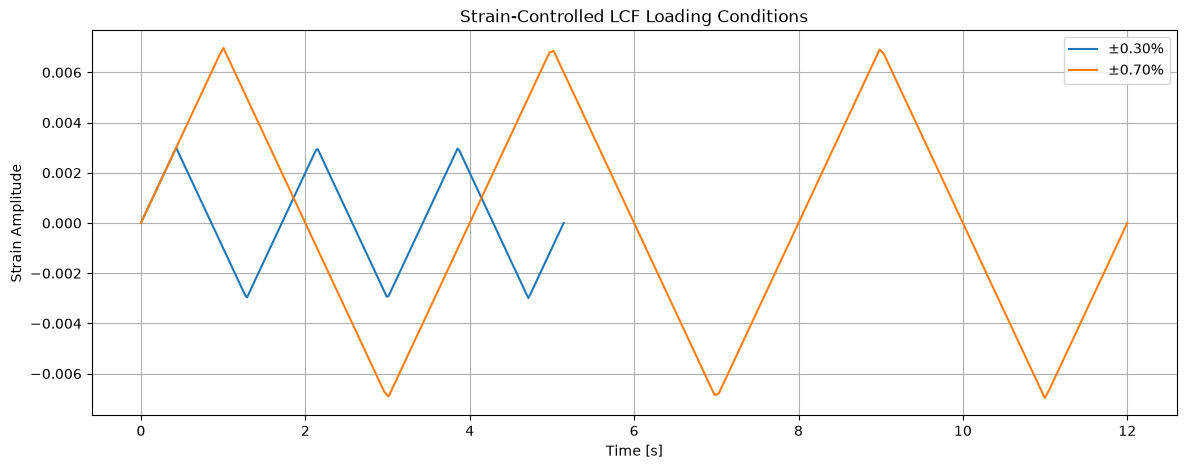

In [8]:
time = torch.zeros((ntime, nbatch), device=device)
temperature = torch.zeros((ntime, nbatch), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

plt.figure(figsize=(14, 5))
for j, amp in enumerate(ranges):
    amplitude = amp.item()
    period = 4.0 * amplitude / strain_rate
    total_time = n_cycles * period

    time_values = torch.linspace(0, total_time, ntime, device=device)
    strain_values = (2.0 * amplitude / torch.pi) * torch.arcsin(
        torch.sin(2.0 * torch.pi * time_values / period)
    )

    loading[:, j, 0] = strain_values
    time[:, j] = time_values
    temperature[:, j] = temperatures[0].item() + 273.15

    plt.plot(
        time[:, j].cpu().numpy(),
        loading[:, j, 0].cpu().numpy(),
        label=rf"$\pm${amp.item() * 100:.2f}%",
    )

plt.xlabel("Time [s]")
plt.ylabel("Strain Amplitude")
plt.title("Strain-Controlled LCF Loading Conditions")
plt.legend()
plt.grid()

Initial data size for 0.3: torch.Size([252])
Initial data size for 0.7: torch.Size([274])
Interpolated data shape:
strain: torch.Size([240, 2, 6])
stress: torch.Size([240, 2, 6])


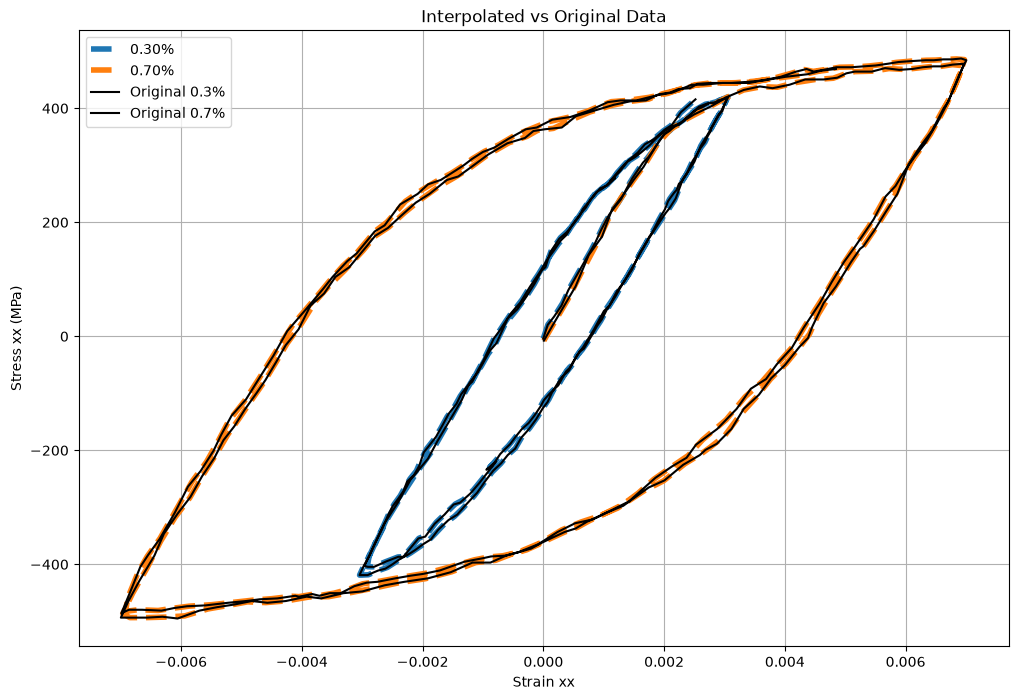

In [9]:
# Initial data shape
for sr_label in raw_strain:
    print(f"Initial data size for {sr_label}: {raw_stress[sr_label].shape}")

exp_stress_data = torch.zeros_like(loading, device=device)
exp_strain_data = torch.zeros_like(loading, device=device)

for i, amp in enumerate(amp_labels):
    sr_label = str(amp)
    f_strain = torch.nn.functional.interpolate(
        raw_strain[sr_label].unsqueeze(0).unsqueeze(0),
        size=ntime,
        mode="linear",
        align_corners=True,
    ).squeeze()
    f_stress = torch.nn.functional.interpolate(
        raw_stress[sr_label].unsqueeze(0).unsqueeze(0),
        size=ntime,
        mode="linear",
        align_corners=True,
    ).squeeze()

    exp_strain_data[:, i, 0] = f_strain
    exp_stress_data[:, i, 0] = f_stress
print(f"Interpolated data shape:")
print(f"strain: {exp_strain_data.shape}")
print(f"stress: {exp_stress_data.shape}")

# Plot interpolated data
plt.figure(figsize=(12, 8))
for i, s_range in enumerate(ranges):
    plt.plot(
        exp_strain_data[:, i, 0].cpu().numpy(),
        exp_stress_data[:, i, 0].cpu().numpy(),
        "--",
        lw=4,
        label=f"{s_range.item() * 100:.2f}%",
    )
for sr_label in raw_strain:
    plt.plot(
        raw_strain[sr_label].cpu().numpy(),
        raw_stress[sr_label].cpu().numpy(),
        color="k",
        label=f"Original {sr_label}%",
    )
plt.xlabel("Strain xx")
plt.ylabel("Stress xx (MPa)")
plt.title("Interpolated vs Original Data")
plt.grid()
plt.legend()
plt.show()

In [10]:
initial_params = {}
print("--- Before Reparameterization ---")
with torch.no_grad():
    for n, p in model.named_parameters():
        if p.dim() == 0:
            p.data = p.data.reshape(1)
        initial_params[n] = p.data.detach().clone()
        print(f"{n}: {p.data}, {p.shape}\n")

--- Before Reparameterization ---
discrete_equations.v_disl_B_k: tensor([6.6000e-11], device='cuda:0'), torch.Size([1])

discrete_equations.v_disl_T_0: tensor([1530.4217], device='cuda:0'), torch.Size([1])

discrete_equations.v_disl_p: tensor([0.6500], device='cuda:0'), torch.Size([1])

discrete_equations.v_disl_q: tensor([1.7000], device='cuda:0'), torch.Size([1])

discrete_equations.v_disl_H_0: tensor([2.1700], device='cuda:0'), torch.Size([1])

discrete_equations.kinharden_C: tensor([35000.], device='cuda:0'), torch.Size([1])

discrete_equations.kinharden_g: tensor([190.], device='cuda:0'), torch.Size([1])

discrete_equations.rho_m_rate_k1: tensor([78000.], device='cuda:0'), torch.Size([1])

discrete_equations.rho_m_rate_k2_0: tensor([6750.], device='cuda:0'), torch.Size([1])

discrete_equations.rho_m_rate_Q_d: tensor([0.0150], device='cuda:0'), torch.Size([1])



In [11]:
with torch.no_grad():
    stress = model(time, temperature, loading)
print(stress.shape)

/tmp/ipykernel_527996/895591253.py:50: UserWarning: pyzag lowered torch._functorch.config.donated_buffer's default to False process-wide. AOTAutograd 'donated buffers' (torch>=2.12) are incompatible with pyzag's retain_graph=True adjoint over torch.compile'd models, which otherwise raises 'compiled with non-empty donated buffers'. To keep donated buffers enabled, restore torch._functorch.config._config['donated_buffer'].default = True -- compiled models differentiated through the adjoint will then error.
  solver = nonlinear.RecursiveNonlinearEquationSolver(


torch.Size([240, 2, 1])


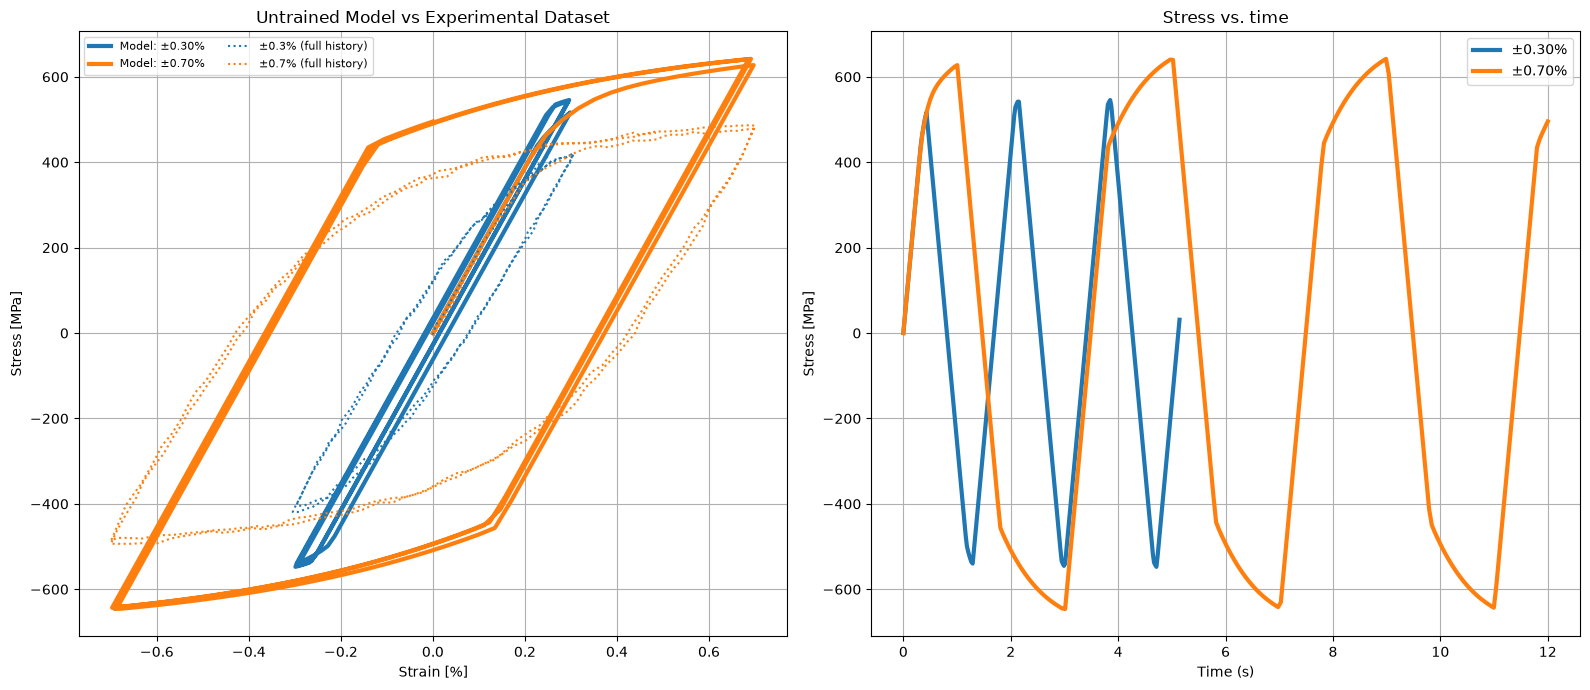

In [12]:
def plot_against_data(stress, title):
    fig, ax = plt.subplots(1, 2, figsize=(16, 7))
    for j, amp in enumerate(ranges):
        ax[0].plot(
            loading[:, j, 0].cpu().numpy() * 100,
            stress[:, j, 0].cpu().numpy(),
            lw=3,
            label=rf"Model: $\pm${amp.item() * 100:.2f}%",
        )
    for i, amp in enumerate(amp_labels):
        ax[0].plot(
            raw_strain[amp].cpu().numpy() * 100,
            raw_stress[amp].cpu().numpy(),
            ":",
            color=f"C{i}",
            label=rf"$\pm${amp}% (full history)",
        )
    ax[0].set_xlabel("Strain [%]")
    ax[0].set_ylabel("Stress [MPa]")
    ax[0].legend(ncol=2, fontsize=8)
    ax[0].set_title(title)
    ax[0].grid()

    for i, amp in enumerate(ranges):
        ax[1].plot(
            time[:, i].cpu().numpy(),
            stress[:, i].cpu().numpy(),
            lw=3,
            label=rf"$\pm${amp.item() * 100:.2f}%",
        )
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylabel("Stress [MPa]")
    ax[1].set_title("Stress vs. time")
    ax[1].legend()
    ax[1].grid()
    plt.tight_layout()
    plt.show()


plot_against_data(stress, "Untrained Model vs Experimental Dataset")

In [13]:
class LogRangeRescale(reparametrization.RangeRescale):
    """Map [0, 1] to [lb, ub] in log space, so an Adam step is a relative change."""

    def __init__(
        self,
        lb: torch.Tensor | float,
        ub: torch.Tensor | float,
        clamp: bool = True,
    ) -> None:
        super().__init__(lb, ub, clamp)
        self.lb = math.log(lb)
        self.ub = math.log(ub)
        self.clamp = clamp

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        if self.clamp:
            X = torch.clamp(X, 0, 1)

        return torch.exp(X * (self.ub - self.lb) + self.lb)

    def reverse(self, X: torch.Tensor) -> torch.Tensor:
        Y = (torch.log(X) - self.lb) / (self.ub - self.lb)

        if self.clamp:
            return torch.clamp(Y, 0, 1)

        return Y

In [14]:
Bk_scaler = LogRangeRescale(
    torch.tensor([1.0e-12], device=device), torch.tensor([1.0e-5], device=device)
)  # MPa*s
T_0_scaler = reparametrization.RangeRescale(
    torch.tensor([100.0], device=device), torch.tensor([5000.0], device=device)
)  # K
p_scaler = LogRangeRescale(torch.tensor([0.01], device=device), torch.tensor([10.0], device=device))
q_scaler = LogRangeRescale(torch.tensor([0.01], device=device), torch.tensor([10.0], device=device))
H0_scaler = reparametrization.RangeRescale(
    torch.tensor([0.1], device=device), torch.tensor([10.0], device=device)
)  # eV
C_scaler = LogRangeRescale(
    torch.tensor([100.0], device=device), torch.tensor([1.0e6], device=device)
)  # MPa
g_scaler = LogRangeRescale(torch.tensor([0.1], device=device), torch.tensor([1.0e4], device=device))
k1_scaler = LogRangeRescale(
    torch.tensor([100.0], device=device), torch.tensor([1.0e7], device=device)
)  # um^-1
k2_0_scaler = LogRangeRescale(
    torch.tensor([0.0001], device=device), torch.tensor([1.0e6], device=device)
)
Q_d_scaler = LogRangeRescale(
    torch.tensor([0.0001], device=device), torch.tensor([1.0], device=device)
)  # eV

model_reparameterizer = reparametrization.Reparameterizer(
    {
        "discrete_equations.v_disl_B_k": Bk_scaler,
        "discrete_equations.v_disl_T_0": T_0_scaler,
        "discrete_equations.v_disl_p": p_scaler,
        "discrete_equations.v_disl_q": q_scaler,
        "discrete_equations.v_disl_H_0": H0_scaler,
        "discrete_equations.kinharden_C": C_scaler,
        "discrete_equations.kinharden_g": g_scaler,
        "discrete_equations.rho_m_rate_k1": k1_scaler,
        "discrete_equations.rho_m_rate_k2_0": k2_0_scaler,
        "discrete_equations.rho_m_rate_Q_d": Q_d_scaler,
    },
    error_not_provided=True,
)
model_reparameterizer(model)
print(f"--- After Reparameterization ---")
initial_params_reparam = {}
for n, p in model.named_parameters():
    initial_params_reparam[n] = p.data.detach().clone()
    print(f"{n}: {p.data}, requires_grad={p.requires_grad}")

--- After Reparameterization ---
discrete_equations.parametrizations.v_disl_B_k.original: tensor([0.2599], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.v_disl_T_0.original: tensor([0.2919], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.v_disl_p.original: tensor([0.6043], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.v_disl_q.original: tensor([0.7435], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.v_disl_H_0.original: tensor([0.2091], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.kinharden_C.original: tensor([0.6360], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.kinharden_g.original: tensor([0.6558], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.rho_m_rate_k1.original: tensor([0.5784], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.rho_m_rate_k2_0.original: tensor([0.7829],

In [ ]:
niter = 1500

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.1,
    patience=150,
    threshold=1e-4,
)

titer = tqdm.tqdm(
    range(niter),
    bar_format="{desc}: {percentage:3.0f}%|{bar}|{n_fmt}/{total_fmt}{postfix}",
)
titer.set_description("Loss:")
loss_history = []

for i in titer:
    optimizer.zero_grad()
    res = model(time, temperature, loading)
    loss = loss_fn(res, exp_stress_data[..., 0:1])

    # --- Bug fix: guard BEFORE backward ---
    if not torch.isfinite(loss):
        titer.set_description(f"Loss: [SKIP bad solve @ iter {i + 1}]")
        continue  # skip backward + step entirely

    loss.backward()
    optimizer.step()
    scheduler.step(loss.item())

    loss_history.append(loss.detach().clone().cpu())
    titer.set_description("Loss: %3.2e" % loss_history[-1])

# --- Plots ---
plt.figure()
plt.loglog(loss_history, label="Training")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.legend()
plt.title("Loss history")

plt.figure()
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Loss history (linear scale)")
plt.show()

Loss: 2.55e+05: :   2%|▏         |37/1500/home/quantumsurfer/anaconda3/envs/neml2/lib/python3.12/site-packages/pyzag/chunktime.py:135: UserWarning: Implicit solve did not succeed.  Results may be inaccurate...
  warnings.warn(
Loss: [SKIP bad solve @ iter 61]: :   4%|▍         |62/1500


KeyboardInterrupt: 